# 02 - TF-IDF multivista + MLP full-batch

Notebook generado automáticamente para el proyecto de predicción de década.

## 0. Instalación y configuración

In [1]:
%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
%pip install pandas numpy scipy scikit-learn matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 7.7 MB/s eta 0:05:41
   ---------------------------------------- 0.0/2.6 GB 30.0 MB/s eta 0:01:28
   ---------------------------------------- 0.0/2.6 GB 46.0 MB/s eta 0:00:57
   ---------------------------------------- 0.0/2.6 GB 39.4 MB/s eta 0:01:06
   ---------------------------------------- 0.0/2.6 GB 35.2 MB/s eta 0:01:14
    --------------------------------------- 0.0/2.6 GB 42.1 MB/s eta 0:01:02
    --------


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 9.8/9.8 MB 96.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -------------------------- ------------- 23.9/36.5 MB 117.5 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 94.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 69.8 MB/s eta 0:00:00
   -------


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =========================
# Imports generales
# =========================

import os
import gc
import math
import time
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp

# =========================
# Visualización
# =========================

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# =========================
# Scikit-learn
# =========================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    classification_report,
    confusion_matrix,
)

# =========================
# PyTorch
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


C:\Users\turing\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# =========================
# Configuración general para GPU
# =========================

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("CONFIGURACIÓN DEL ENTORNO")
print("=" * 70)
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA PyTorch:", torch.version.cuda)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memoria GPU:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
    print("Memoria asignada:", round(torch.cuda.memory_allocated() / 1024**3, 3), "GB")
    print("Memoria reservada:", round(torch.cuda.memory_reserved() / 1024**3, 3), "GB")

print("=" * 70)


CONFIGURACIÓN DEL ENTORNO
PyTorch: 2.12.0+cu126
CUDA disponible: True
CUDA PyTorch: 12.6
Device: cuda
GPU: NVIDIA GeForce RTX 4090
Memoria GPU: 23.99 GB
Memoria asignada: 0.0 GB
Memoria reservada: 0.0 GB


In [4]:
# =========================
# Limpieza segura de memoria
# =========================

def clean_memory(verbose=True):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        if verbose:
            print("Memoria asignada:", round(torch.cuda.memory_allocated() / 1024**3, 3), "GB")
            print("Memoria reservada:", round(torch.cuda.memory_reserved() / 1024**3, 3), "GB")

clean_memory()


Memoria asignada: 0.0 GB
Memoria reservada: 0.0 GB


## 1. Configuración del experimento

In [5]:
# =========================
# Configuración del experimento: TF-IDF multivista + MLP full-batch
# =========================

TRAIN_PATH = "train.csv"
TEXT_COL = "text"
LABEL_COL = "decade"

CHAR_NGRAM_RANGE = (2, 6)
CHAR_WB_NGRAM_RANGE = (3, 6)
WORD_NGRAM_RANGE = (1, 2)

CHAR_MAX_FEATURES = 220_000
CHAR_WB_MAX_FEATURES = 160_000
WORD_MAX_FEATURES = 100_000

MIN_DF = 2
MAX_DF = 1.0

# Full-batch usa mucha memoria; si falla, baja hidden_1.
HIDDEN_1 = 768
HIDDEN_2 = 384
HIDDEN_3 = 192
DROPOUT = 0.35

EPOCHS = 30
PATIENCE = 2

# Batch para predicción/evaluación solamente. El entrenamiento usa full batch.
BATCH_SIZE = 512 if DEVICE.type == "cuda" else 128

LR = 1e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
GRAD_CLIP = 1.0

CHECKPOINT_DIR = "checkpoints_02_tfidf_multiview_mlp_fullbatch"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best.pt")
LAST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "last.pt")

print("Entrenamiento full-batch activado.")
print("Checkpoints:", CHECKPOINT_DIR)


Entrenamiento full-batch activado.
Checkpoints: checkpoints_02_tfidf_multiview_mlp_fullbatch


## 2. Datos y etiquetas

In [6]:
# =========================
# Carga de datos y mapeo de etiquetas
# =========================

df = pd.read_csv(TRAIN_PATH)

assert TEXT_COL in df.columns, f"No existe columna '{TEXT_COL}'"
assert LABEL_COL in df.columns, f"No existe columna '{LABEL_COL}'"

df = df[[TEXT_COL, LABEL_COL]].copy()
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)

decades = sorted(df[LABEL_COL].unique())
decade_to_idx = {decade: idx for idx, decade in enumerate(decades)}
idx_to_decade = {idx: decade for decade, idx in decade_to_idx.items()}

df["label_idx"] = df[LABEL_COL].map(decade_to_idx)

NUM_CLASSES = len(decades)

print("Shape:", df.shape)
print("Número de clases:", NUM_CLASSES)
print("Década mínima:", min(decades))
print("Década máxima:", max(decades))
print("Clases:", decades)

# Chequeos explícitos de etiquetas extremas
assert min(decades) == 150, "La década mínima no es 150. Revisa el dataset."
assert max(decades) == 188, "La década máxima no es 188. Revisa el dataset."
assert NUM_CLASSES == 39, f"Se esperaban 39 clases, pero hay {NUM_CLASSES}."

display(df.head())
display(df[LABEL_COL].value_counts().sort_index())


Shape: (31403, 3)
Número de clases: 39
Década mínima: 150
Década máxima: 188
Clases: [np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154), np.int64(155), np.int64(156), np.int64(157), np.int64(158), np.int64(159), np.int64(160), np.int64(161), np.int64(162), np.int64(163), np.int64(164), np.int64(165), np.int64(166), np.int64(167), np.int64(168), np.int64(169), np.int64(170), np.int64(171), np.int64(172), np.int64(173), np.int64(174), np.int64(175), np.int64(176), np.int64(177), np.int64(178), np.int64(179), np.int64(180), np.int64(181), np.int64(182), np.int64(183), np.int64(184), np.int64(185), np.int64(186), np.int64(187), np.int64(188)]


,text,decade,label_idx
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,14
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,32
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,7
3,Caistro el M a y o r a i .] Del ape...,163,13
4,\nlos que panden macho ; y \notros en l...,166,16


decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809
Name: count, dtype: int64

In [7]:
# =========================
# Split train / validation / test
# =========================

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label_idx"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_idx"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

# Verificar que las clases extremas estén en todos los splits
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    present = set(part[LABEL_COL].unique())
    print(name, "contiene 150:", 150 in present, "| contiene 188:", 188 in present)


Train: (25122, 3)
Val: (3140, 3)
Test: (3141, 3)
train contiene 150: True | contiene 188: True
val contiene 150: True | contiene 188: True
test contiene 150: True | contiene 188: True


## 3. TF-IDF multivista

In [8]:
# =========================
# Vectorizadores TF-IDF multivista
# =========================

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=CHAR_NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=CHAR_MAX_FEATURES,
    sublinear_tf=True,
    lowercase=False,
    strip_accents=None,
    dtype=np.float32
)

char_wb_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=CHAR_WB_NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=CHAR_WB_MAX_FEATURES,
    sublinear_tf=True,
    lowercase=False,
    strip_accents=None,
    dtype=np.float32
)

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=WORD_NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=WORD_MAX_FEATURES,
    sublinear_tf=True,
    lowercase=False,
    strip_accents=None,
    token_pattern=r"(?u)\b\w+\b",
    dtype=np.float32
)

train_texts = train_df[TEXT_COL].tolist()
val_texts = val_df[TEXT_COL].tolist()
test_texts = test_df[TEXT_COL].tolist()

print("Ajustando char TF-IDF...")
X_train_char = char_vectorizer.fit_transform(train_texts)
X_val_char = char_vectorizer.transform(val_texts)
X_test_char = char_vectorizer.transform(test_texts)

print("Ajustando char_wb TF-IDF...")
X_train_char_wb = char_wb_vectorizer.fit_transform(train_texts)
X_val_char_wb = char_wb_vectorizer.transform(val_texts)
X_test_char_wb = char_wb_vectorizer.transform(test_texts)

print("Ajustando word TF-IDF...")
X_train_word = word_vectorizer.fit_transform(train_texts)
X_val_word = word_vectorizer.transform(val_texts)
X_test_word = word_vectorizer.transform(test_texts)

X_train = sp.hstack([X_train_char, X_train_char_wb, X_train_word], format="csr", dtype=np.float32)
X_val = sp.hstack([X_val_char, X_val_char_wb, X_val_word], format="csr", dtype=np.float32)
X_test = sp.hstack([X_test_char, X_test_char_wb, X_test_word], format="csr", dtype=np.float32)

y_train = train_df["label_idx"].values.astype(np.int64)
y_val = val_df["label_idx"].values.astype(np.int64)
y_test = test_df["label_idx"].values.astype(np.int64)

INPUT_DIM = X_train.shape[1]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Input dim:", INPUT_DIM)
print("Sparsity train:", 1.0 - (X_train.nnz / (X_train.shape[0] * X_train.shape[1])))


Ajustando char TF-IDF...
Ajustando char_wb TF-IDF...
Ajustando word TF-IDF...
X_train: (25122, 480000)
X_val: (3140, 480000)
X_test: (3141, 480000)
Input dim: 480000
Sparsity train: 0.9956873582749516


In [9]:
# =========================
# Dataset sparse por índices
# =========================

class SparseIndexDataset(Dataset):
    def __init__(self, labels):
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"idx": idx, "label": self.labels[idx]}


def sparse_collate_fn(batch):
    indices = torch.tensor([item["idx"] for item in batch], dtype=torch.long)
    labels = torch.stack([item["label"] for item in batch])
    return {"indices": indices, "labels": labels}


class EvalSparseIndexDataset(Dataset):
    def __init__(self, indices):
        self.indices = torch.tensor(indices, dtype=torch.long)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return {"idx": self.indices[idx]}


def eval_sparse_collate_fn(batch):
    indices = torch.stack([item["idx"] for item in batch])
    return {"indices": indices}


def csr_batch_to_torch_sparse(X_csr_batch, device=DEVICE):
    X_coo = X_csr_batch.tocoo()
    indices = torch.tensor(np.vstack((X_coo.row, X_coo.col)), dtype=torch.long)
    values = torch.tensor(X_coo.data, dtype=torch.float32)
    shape = torch.Size(X_coo.shape)
    return torch.sparse_coo_tensor(indices, values, shape, dtype=torch.float32).coalesce().to(device)


train_dataset = SparseIndexDataset(y_train)
val_dataset = SparseIndexDataset(y_val)
test_dataset = SparseIndexDataset(y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=sparse_collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sparse_collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sparse_collate_fn, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 50
Val batches: 7
Test batches: 7


## 4. Modelo

In [10]:
# =========================
# MLP potente para TF-IDF sparse
# =========================

class SparseTfidfMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_1=HIDDEN_1, hidden_2=HIDDEN_2, hidden_3=HIDDEN_3, dropout=DROPOUT):
        super().__init__()

        # Primera capa manual para soportar input sparse
        self.fc1_weight = nn.Parameter(torch.empty(hidden_1, input_dim))
        self.fc1_bias = nn.Parameter(torch.zeros(hidden_1))

        self.norm1 = nn.LayerNorm(hidden_1)
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.norm2 = nn.LayerNorm(hidden_2)
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(hidden_2, hidden_3)
        self.norm3 = nn.LayerNorm(hidden_3)
        self.dropout3 = nn.Dropout(dropout)

        self.out = nn.Linear(hidden_3, num_classes)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.fc1_weight)
        nn.init.zeros_(self.fc1_bias)
        for module in [self.fc2, self.fc3, self.out]:
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x_sparse):
        x = torch.sparse.mm(x_sparse, self.fc1_weight.t()) + self.fc1_bias
        x = self.norm1(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.norm2(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.norm3(x)
        x = F.gelu(x)
        x = self.dropout3(x)

        return self.out(x)


model = SparseTfidfMLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {total_params:,}")


SparseTfidfMLP(
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.35, inplace=False)
  (fc2): Linear(in_features=768, out_features=384, bias=True)
  (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout2): Dropout(p=0.35, inplace=False)
  (fc3): Linear(in_features=384, out_features=192, bias=True)
  (norm3): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout3): Dropout(p=0.35, inplace=False)
  (out): Linear(in_features=192, out_features=39, bias=True)
)
Total parameters: 369,020,199


In [11]:
# =========================
# Métricas
# =========================

idx_to_decade_tensor = torch.tensor([idx_to_decade[i] for i in range(NUM_CLASSES)], dtype=torch.long, device=DEVICE)

def compute_metrics_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    pred_decades = idx_to_decade_tensor[preds]
    true_decades = idx_to_decade_tensor[labels]
    abs_error = torch.abs(pred_decades - true_decades)

    return {
        "acc": (preds == labels).float().mean().item(),
        "acc_pm1": (abs_error <= 1).float().mean().item(),
        "acc_pm2": (abs_error <= 2).float().mean().item(),
        "mae": abs_error.float().mean().item(),
    }


In [12]:
# =========================
# Funciones full-batch
# =========================

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

def fullbatch_to_device(X_matrix, y_array):
    X_tensor = csr_batch_to_torch_sparse(X_matrix, device=DEVICE)
    y_tensor = torch.tensor(y_array, dtype=torch.long, device=DEVICE)
    return X_tensor, y_tensor


def train_one_epoch_fullbatch(model, X_matrix, y_array):
    model.train()
    X_tensor, labels = fullbatch_to_device(X_matrix, y_array)

    optimizer.zero_grad(set_to_none=True)
    logits = model(X_tensor)
    loss = criterion(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    metrics = compute_metrics_from_logits(logits.detach(), labels.detach())
    metrics["loss"] = loss.item()

    del X_tensor, labels, logits, loss
    clean_memory(verbose=False)

    return metrics


@torch.no_grad()
def evaluate_fullbatch(model, X_matrix, y_array, desc="Evaluating"):
    model.eval()
    X_tensor, labels = fullbatch_to_device(X_matrix, y_array)

    logits = model(X_tensor)
    loss = criterion(logits, labels)

    metrics = compute_metrics_from_logits(logits.detach(), labels.detach())
    metrics["loss"] = loss.item()

    del X_tensor, labels, logits, loss
    clean_memory(verbose=False)

    return metrics


# Para predicción/submission usamos mini-batches de inferencia, no afecta la condición de entrenamiento full-batch.
@torch.no_grad()
def predict_sparse(model, X_matrix, batch_size=BATCH_SIZE):
    model.eval()
    indices = np.arange(X_matrix.shape[0])
    ds = EvalSparseIndexDataset(indices)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=eval_sparse_collate_fn, num_workers=0)

    all_preds = []
    all_logits = []

    for batch in tqdm(loader, desc="Predicting", leave=False):
        batch_indices = batch["indices"].numpy()
        X_batch = csr_batch_to_torch_sparse(X_matrix[batch_indices], device=DEVICE)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_logits.append(logits.detach().cpu())

    return np.array(all_preds), torch.cat(all_logits, dim=0)


## 5. Entrenamiento full-batch

In [13]:
# =========================
# Loop principal full-batch: prioriza accuracy
# =========================

history = []
best_val_acc = -1.0
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 70)

    train_metrics = train_one_epoch_fullbatch(model, X_train, y_train)
    val_metrics = evaluate_fullbatch(model, X_val, y_val, desc="Validation")
    scheduler.step(val_metrics["acc"])

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "train_pm1": train_metrics["acc_pm1"],
        "train_pm2": train_metrics["acc_pm2"],
        "train_mae": train_metrics["mae"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_pm1": val_metrics["acc_pm1"],
        "val_pm2": val_metrics["acc_pm2"],
        "val_mae": val_metrics["mae"],
    }
    history.append(row)

    print(f"Train loss {row['train_loss']:.4f} | acc {row['train_acc']:.4f} | MAE {row['train_mae']:.3f}")
    print(f"Val   loss {row['val_loss']:.4f} | acc {row['val_acc']:.4f} | MAE {row['val_mae']:.3f} | ±1 {row['val_pm1']:.4f}")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "best_val_acc": best_val_acc,
        "vectorizers": {"char": char_vectorizer, "char_wb": char_wb_vectorizer, "word": word_vectorizer},
        "decade_to_idx": decade_to_idx,
        "idx_to_decade": idx_to_decade,
        "decades": decades,
        "config": {
            "INPUT_DIM": INPUT_DIM,
            "NUM_CLASSES": NUM_CLASSES,
            "HIDDEN_1": HIDDEN_1,
            "HIDDEN_2": HIDDEN_2,
            "HIDDEN_3": HIDDEN_3,
            "DROPOUT": DROPOUT,
        }
    }, LAST_MODEL_PATH)

    if val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "best_val_acc": best_val_acc,
            "best_val_metrics": val_metrics,
            "vectorizers": {"char": char_vectorizer, "char_wb": char_wb_vectorizer, "word": word_vectorizer},
            "decade_to_idx": decade_to_idx,
            "idx_to_decade": idx_to_decade,
            "decades": decades,
            "config": {
                "INPUT_DIM": INPUT_DIM,
                "NUM_CLASSES": NUM_CLASSES,
                "HIDDEN_1": HIDDEN_1,
                "HIDDEN_2": HIDDEN_2,
                "HIDDEN_3": HIDDEN_3,
                "DROPOUT": DROPOUT,
            }
        }, BEST_MODEL_PATH)

        print("Nuevo mejor checkpoint guardado.")
    else:
        epochs_without_improvement += 1
        print(f"Sin mejora por {epochs_without_improvement} época(s).")

    clean_memory(verbose=False)

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping activado.")
        break

print("Mejor época:", best_epoch)
print("Mejor val accuracy:", best_val_acc)



Epoch 1/30
----------------------------------------------------------------------
Train loss 4.2213 | acc 0.0252 | MAE 13.241
Val   loss 3.6233 | acc 0.0815 | MAE 9.174 | ±1 0.1599
Nuevo mejor checkpoint guardado.

Epoch 2/30
----------------------------------------------------------------------
Train loss 3.5445 | acc 0.0937 | MAE 10.740
Val   loss 3.3242 | acc 0.1290 | MAE 7.532 | ±1 0.2325
Nuevo mejor checkpoint guardado.

Epoch 3/30
----------------------------------------------------------------------
Train loss 3.0738 | acc 0.2029 | MAE 8.566
Val   loss 3.1558 | acc 0.1678 | MAE 6.190 | ±1 0.2834
Nuevo mejor checkpoint guardado.

Epoch 4/30
----------------------------------------------------------------------
Train loss 2.6625 | acc 0.3382 | MAE 6.570
Val   loss 3.0869 | acc 0.1952 | MAE 5.910 | ±1 0.3166
Nuevo mejor checkpoint guardado.

Epoch 5/30
----------------------------------------------------------------------
Train loss 2.3512 | acc 0.4586 | MAE 5.188
Val   loss 3.056

## 6. Evaluación, matriz de confusión y submission normal

In [15]:
# =========================
# Función de evaluación segura por batches
# =========================

@torch.no_grad()
def evaluate(model, X_matrix, y_true, criterion, batch_size=1024, desc="Evaluating"):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_examples = 0

    n = X_matrix.shape[0]

    for start in tqdm(range(0, n, batch_size), desc=desc):
        end = min(start + batch_size, n)

        X_batch = torch.tensor(
            X_matrix[start:end].toarray(),
            dtype=torch.float32,
            device=DEVICE
        )

        labels = torch.tensor(
            y_true[start:end],
            dtype=torch.long,
            device=DEVICE
        )

        logits = model(X_batch)
        loss = criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)

        batch_n = labels.size(0)
        total_loss += loss.item() * batch_n
        total_examples += batch_n

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = np.mean(all_preds == all_labels)

    pred_decades = np.array([idx_to_decade[int(i)] for i in all_preds])
    true_decades = np.array([idx_to_decade[int(i)] for i in all_labels])

    abs_errors = np.abs(pred_decades - true_decades)

    return {
        "loss": total_loss / total_examples,
        "acc": acc,
        "mae": abs_errors.mean(),
        "acc_pm1": np.mean(abs_errors <= 1),
        "acc_pm2": np.mean(abs_errors <= 2),
        "preds": all_preds,
        "labels": all_labels,
    }

,epoch,lr,train_loss,train_acc,train_pm1,train_pm2,train_mae,val_loss,val_acc,val_pm1,val_pm2,val_mae
0,1,0.00010,4.221345,0.025157,0.073641,0.120771,13.240746,3.623292,0.081529,0.159873,0.229299,9.173567
1,2,0.00010,3.544507,0.093663,0.148316,0.203646,10.739830,3.324178,0.128981,0.232484,0.310191,7.532484
2,3,0.00010,3.073849,0.202890,0.268729,0.330905,8.565958,3.155849,0.167834,0.283439,0.379618,6.190127
3,4,0.00010,2.662519,0.338229,0.401640,0.460274,6.569939,3.086862,0.195223,0.316561,0.420064,5.909554
4,5,0.00010,2.351223,0.458642,0.511584,0.565679,5.187843,3.056388,0.195223,0.315605,0.427070,5.895860
5,6,0.00010,2.103226,0.565202,0.609068,0.651700,4.178171,3.015126,0.209554,0.328662,0.442994,5.618790
6,7,0.00010,1.891015,0.665552,0.698034,0.730396,3.231192,2.972175,0.225159,0.348089,0.463694,5.297452
7,8,0.00010,1.714104,0.749861,0.775018,0.798941,2.423573,2.948141,0.236306,0.361783,0.485032,5.005414
8,9,0.00010,1.562486,0.815859,0.835881,0.854669,1.811162,2.933443,0.242675,0.376752,0.493312,4.890446
9,10,0.00010,1.430766,0.865894,0.881021,0.894515,1.297667,2.922705,0.246815,0.382166,0.497134,4.861465


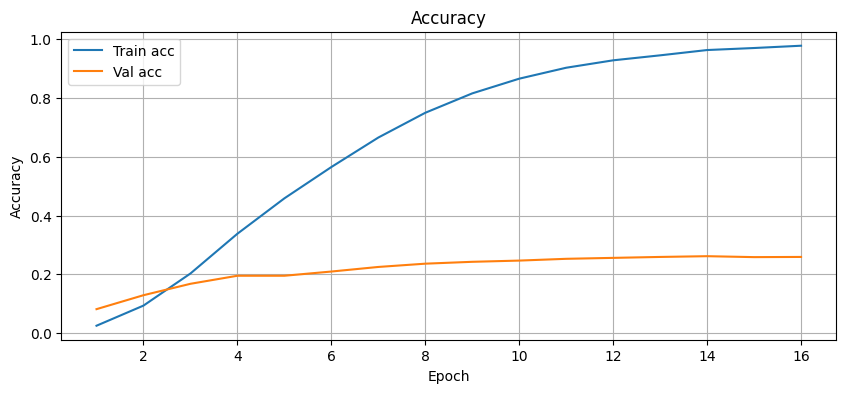

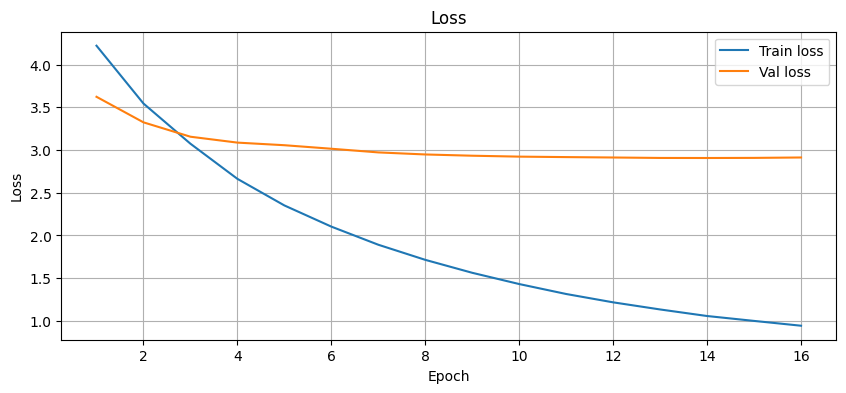

Mejor época: 14
Best val acc: 0.2617834508419037
TEST: {'acc': 0.258516401052475, 'acc_pm1': 0.39923590421676636, 'acc_pm2': 0.5179879069328308, 'mae': 4.684176921844482, 'loss': 2.9071593284606934}


Accuracy test: 0.25851639605221266
MAE test: 4.684177013689908


,150,151,152,153,154,155,156,157,158,159,...,179,180,181,182,183,184,185,186,187,188
150,62,2,1,0,3,0,0,2,0,0,...,0,1,0,0,1,0,0,1,0,1
151,2,61,0,1,5,2,0,0,0,0,...,1,0,0,1,1,1,2,1,1,0
152,0,7,44,6,6,2,1,1,0,0,...,0,0,1,0,1,0,2,0,1,1
153,0,10,0,54,9,0,1,1,0,0,...,0,0,0,1,0,0,0,1,0,0
154,1,8,0,6,56,3,0,1,1,1,...,1,1,0,0,0,0,0,1,0,1
155,0,9,0,9,9,25,2,4,3,4,...,0,0,0,2,0,0,1,1,2,1
156,1,3,1,3,5,4,28,4,5,4,...,1,1,1,1,0,0,0,1,0,1
157,1,4,0,8,1,5,4,26,2,10,...,0,0,0,0,0,0,0,0,0,0
158,0,0,0,2,4,4,3,12,15,15,...,0,1,0,0,0,1,0,0,0,0
159,1,2,0,2,2,5,4,5,5,33,...,0,0,0,0,0,1,0,0,0,0


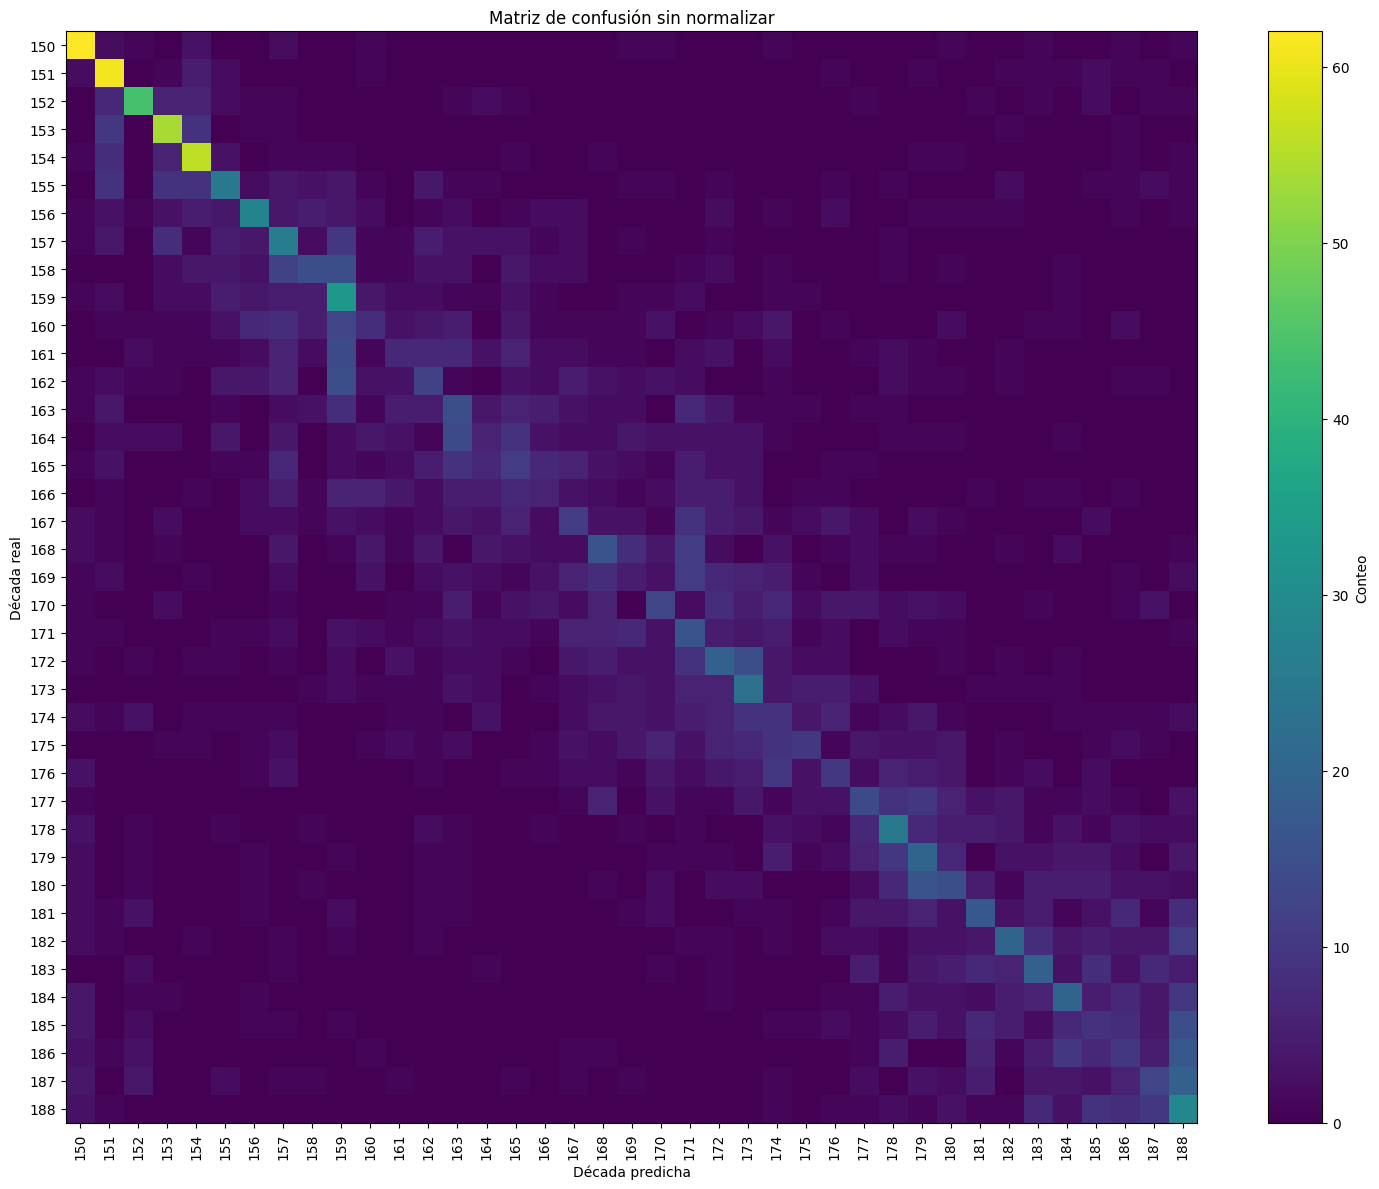

Predicciones por clase en test:


150    114
151    129
152     74
153    103
154    108
155     70
156     70
157    116
158     47
159    143
160     49
161     43
162     73
163     93
164     52
165     77
166     48
167     71
168     78
169     59
170     67
171    105
172    100
173     97
174     84
175     40
176     55
177     70
178     96
179    103
180     77
181     66
182     65
183     75
184     76
185     72
186     77
187     63
188    136
Name: count, dtype: int64

Submission guardada: submission_validation_model.csv


,id,answer
0,0,181
1,1,184
2,2,150
3,3,169
4,4,153


Predicciones por década en eval:


answer
150    128
151    150
152     90
153    128
154    115
155     61
156     77
157    125
158     35
159    155
160     88
161     43
162     90
163    114
164     60
165     75
166     59
167     93
168     86
169     73
170     67
171    100
172    100
173    110
174     84
175     59
176     71
177     78
178     99
179     95
180     85
181     71
182     78
183     78
184     96
185     88
186     76
187     83
188    127
Name: count, dtype: int64

In [17]:
# =========================
# Curvas, test, matriz de confusión y submission del modelo con validación
# =========================

history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train acc")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Cargar checkpoint en CPU para evitar OOM
checkpoint = torch.load(BEST_MODEL_PATH, map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Mejor época:", checkpoint["epoch"])
print("Best val acc:", checkpoint["best_val_acc"])

test_metrics = evaluate_fullbatch(model, X_test, y_test, desc="Test")
print("TEST:", test_metrics)

test_pred_idx, test_logits = predict_sparse(model, X_test)
y_true = y_test
y_pred = test_pred_idx

print("Accuracy test:", accuracy_score(y_true, y_pred))
print("MAE test:", mean_absolute_error([idx_to_decade[i] for i in y_true], [idx_to_decade[i] for i in y_pred]))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=[idx_to_decade[i] for i in range(NUM_CLASSES)], columns=[idx_to_decade[i] for i in range(NUM_CLASSES)])
display(cm_df)

plt.figure(figsize=(15, 12))
plt.imshow(cm, aspect="auto")
plt.title("Matriz de confusión sin normalizar")
plt.xlabel("Década predicha")
plt.ylabel("Década real")
plt.xticks(np.arange(NUM_CLASSES), [idx_to_decade[i] for i in range(NUM_CLASSES)], rotation=90)
plt.yticks(np.arange(NUM_CLASSES), [idx_to_decade[i] for i in range(NUM_CLASSES)])
plt.colorbar(label="Conteo")
plt.tight_layout()
plt.show()

print("Predicciones por clase en test:")
display(pd.Series([idx_to_decade[i] for i in y_pred]).value_counts().sort_index())

# Submission con modelo de validación
EVAL_PATH = "eval.csv"
SUBMISSION_PATH = "submission_validation_model.csv"

eval_df = pd.read_csv(EVAL_PATH)
assert "id" in eval_df.columns and "text" in eval_df.columns
eval_df["text"] = eval_df["text"].fillna("").astype(str)

vectorizers = checkpoint["vectorizers"]
X_eval = sp.hstack([
    vectorizers["char"].transform(eval_df["text"].tolist()),
    vectorizers["char_wb"].transform(eval_df["text"].tolist()),
    vectorizers["word"].transform(eval_df["text"].tolist()),
], format="csr", dtype=np.float32)

eval_pred_idx, _ = predict_sparse(model, X_eval)
answers = [idx_to_decade[int(i)] for i in eval_pred_idx]

submission = pd.DataFrame({"id": eval_df["id"].values, "answer": answers})
submission.to_csv(SUBMISSION_PATH, index=False)

print("Submission guardada:", SUBMISSION_PATH)
display(submission.head())
print("Predicciones por década en eval:")
display(submission["answer"].value_counts().sort_index())


## 7. Entrenamiento full-data full-batch y submission final

In [18]:
# =========================
# Entrenamiento final full-data con full-batch y submission
# =========================

FINAL_EPOCHS = int(checkpoint["epoch"])
FINAL_CHECKPOINT_DIR = CHECKPOINT_DIR + "_final"
os.makedirs(FINAL_CHECKPOINT_DIR, exist_ok=True)
FINAL_MODEL_PATH = os.path.join(FINAL_CHECKPOINT_DIR, "final_full_data.pt")

print("Entrenando modelo final full-batch con todo train.csv por", FINAL_EPOCHS, "épocas.")

full_texts = df[TEXT_COL].tolist()
y_full = df["label_idx"].values.astype(np.int64)

final_char_vectorizer = TfidfVectorizer(
    analyzer="char", ngram_range=CHAR_NGRAM_RANGE, min_df=MIN_DF, max_df=MAX_DF,
    max_features=CHAR_MAX_FEATURES, sublinear_tf=True, lowercase=False,
    strip_accents=None, dtype=np.float32
)
final_char_wb_vectorizer = TfidfVectorizer(
    analyzer="char_wb", ngram_range=CHAR_WB_NGRAM_RANGE, min_df=MIN_DF, max_df=MAX_DF,
    max_features=CHAR_WB_MAX_FEATURES, sublinear_tf=True, lowercase=False,
    strip_accents=None, dtype=np.float32
)
final_word_vectorizer = TfidfVectorizer(
    analyzer="word", ngram_range=WORD_NGRAM_RANGE, min_df=MIN_DF, max_df=MAX_DF,
    max_features=WORD_MAX_FEATURES, sublinear_tf=True, lowercase=False,
    strip_accents=None, token_pattern=r"(?u)\b\w+\b", dtype=np.float32
)

print("Ajustando TF-IDF final...")
X_full = sp.hstack([
    final_char_vectorizer.fit_transform(full_texts),
    final_char_wb_vectorizer.fit_transform(full_texts),
    final_word_vectorizer.fit_transform(full_texts),
], format="csr", dtype=np.float32)

FINAL_INPUT_DIM = X_full.shape[1]
print("X_full:", X_full.shape)

try:
    model.to("cpu")
    del model
except Exception:
    pass
clean_memory()

final_model = SparseTfidfMLP(FINAL_INPUT_DIM, NUM_CLASSES).to(DEVICE)
final_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=max(FINAL_EPOCHS, 1))

def train_final_fullbatch_epoch(model, X_matrix, y_array):
    model.train()
    X_tensor = csr_batch_to_torch_sparse(X_matrix, device=DEVICE)
    labels = torch.tensor(y_array, dtype=torch.long, device=DEVICE)

    final_optimizer.zero_grad(set_to_none=True)
    logits = model(X_tensor)
    loss = final_criterion(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    final_optimizer.step()

    metrics = compute_metrics_from_logits(logits.detach(), labels.detach())
    metrics["loss"] = loss.item()

    del X_tensor, labels, logits, loss
    clean_memory(verbose=False)
    return metrics

final_history = []
for epoch in range(1, FINAL_EPOCHS + 1):
    print(f"Final epoch {epoch}/{FINAL_EPOCHS}")
    m = train_final_fullbatch_epoch(final_model, X_full, y_full)
    final_scheduler.step()
    final_history.append({"epoch": epoch, **m, "lr": final_optimizer.param_groups[0]["lr"]})
    print(m)

torch.save({
    "epoch": FINAL_EPOCHS,
    "model_state_dict": final_model.state_dict(),
    "history": final_history,
    "vectorizers": {"char": final_char_vectorizer, "char_wb": final_char_wb_vectorizer, "word": final_word_vectorizer},
    "decade_to_idx": decade_to_idx,
    "idx_to_decade": idx_to_decade,
    "decades": decades,
    "config": {"INPUT_DIM": FINAL_INPUT_DIM, "NUM_CLASSES": NUM_CLASSES, "HIDDEN_1": HIDDEN_1, "HIDDEN_2": HIDDEN_2, "HIDDEN_3": HIDDEN_3, "DROPOUT": DROPOUT}
}, FINAL_MODEL_PATH)

print("Modelo final guardado:", FINAL_MODEL_PATH)

FINAL_SUBMISSION_PATH = "submission_full_data_model.csv"
eval_df = pd.read_csv(EVAL_PATH)
eval_df["text"] = eval_df["text"].fillna("").astype(str)

X_eval_final = sp.hstack([
    final_char_vectorizer.transform(eval_df["text"].tolist()),
    final_char_wb_vectorizer.transform(eval_df["text"].tolist()),
    final_word_vectorizer.transform(eval_df["text"].tolist()),
], format="csr", dtype=np.float32)

final_preds, _ = predict_sparse(final_model, X_eval_final, batch_size=BATCH_SIZE)
answers = [idx_to_decade[int(i)] for i in final_preds]

submission_final = pd.DataFrame({"id": eval_df["id"].values, "answer": answers})
submission_final.to_csv(FINAL_SUBMISSION_PATH, index=False)

print("Submission full-data guardada:", FINAL_SUBMISSION_PATH)
display(submission_final.head())
display(submission_final["answer"].value_counts().sort_index())


Entrenando modelo final full-batch con todo train.csv por 14 épocas.
Ajustando TF-IDF final...
X_full: (31403, 480000)
Memoria asignada: 2.766 GB
Memoria reservada: 4.414 GB
Final epoch 1/14
{'acc': 0.025698181241750717, 'acc_pm1': 0.07336878776550293, 'acc_pm2': 0.11600802093744278, 'mae': 13.916631698608398, 'loss': 4.1843767166137695}
Final epoch 2/14
{'acc': 0.08518294245004654, 'acc_pm1': 0.1453045904636383, 'acc_pm2': 0.20599941909313202, 'mae': 10.426169395446777, 'loss': 3.5751185417175293}
Final epoch 3/14
{'acc': 0.18861255049705505, 'acc_pm1': 0.26194947957992554, 'acc_pm2': 0.3279304504394531, 'mae': 8.244657516479492, 'loss': 3.109653949737549}
Final epoch 4/14
{'acc': 0.3016272187232971, 'acc_pm1': 0.36999648809432983, 'acc_pm2': 0.436932772397995, 'mae': 6.846734046936035, 'loss': 2.7447402477264404}
Final epoch 5/14
{'acc': 0.4056618809700012, 'acc_pm1': 0.46734386682510376, 'acc_pm2': 0.526319146156311, 'mae': 5.992611885070801, 'loss': 2.4607768058776855}
Final epoch 

Submission full-data guardada: submission_full_data_model.csv


,id,answer
0,0,181
1,1,179
2,2,150
3,3,172
4,4,153


answer
150    132
151    154
152    107
153    113
154    132
155     66
156     75
157     72
158    161
159    152
160    131
161    111
162     23
163     49
164     37
165    152
166     40
167     57
168    102
169     14
170    110
171    126
172     61
173    102
174     88
175     61
176     95
177     47
178     89
179    172
180     92
181    111
182     58
183     55
184     48
185     38
186     58
187     66
188    133
Name: count, dtype: int64